# ASC speed changes with resolution

In [1]:
import cosima_cookbook as cc
from cosima_cookbook import distributed as ccd
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:44727/status,
Dashboard: http://127.0.0.1:44727/status,Workers: 28
Total threads: 28,Total memory: 251.18 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44575,Workers: 28
Dashboard: http://127.0.0.1:44727/status,Total threads: 28
Started: Just now,Total memory: 251.18 GiB
Comm: tcp://127.0.0.1:40821,Total threads: 1
Dashboard: http://127.0.0.1:35685/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:39503,


In [7]:
exp01 = 'panant-01-zstar-ACCESSyr2'
exp005 = 'panant-005-zstar-ACCESSyr2'
exp0025 = 'panant-0025-zstar-ACCESSyr2'
start_time= '2000-01'
end_time= '2000-02'
lat_range = slice(-90,-59)
isobath_depth = 1000
rho_0 = 1035.0

session = cc.database.create_session()

basedir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'


Importing surface speed

In [10]:
#panan01
U01 = cc.querying.getvar(exp01,'uo',session,frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=start_time).isel(z_l=0)
V01 = cc.querying.getvar(exp01,'vo',session,frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=start_time).isel(z_l=0)
#panan005
U005 = cc.querying.getvar(exp005,'uo',session,frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=start_time).isel(z_l=0)
V005 = cc.querying.getvar(exp005,'vo',session,frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=start_time).isel(z_l=0)
#panan0025
U0025 = cc.querying.getvar(exp0025,'uo',session,frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=start_time).isel(z_l=0)
V0025 = cc.querying.getvar(exp0025,'vo',session,frequency='1 monthly',start_time=start_time,end_time=end_time).sel(time=start_time).isel(z_l=0)



/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


0.3.0


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


0.3.0


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


0.3.0
0.3.0
0.3.0


In [13]:
#interpoalting all data to the U grid to calculate the speed
V01 = V01.interp(yq=U01.yh,xh=U01.xq)
V005 = V005.interp(yq=U005.yh,xh=U005.xq)
V0025 = V0025.interp(yq=U0025.yh,xh=U0025.xq)

In [22]:
#calculating speed
VVEL01=(((U01**2) + (V01**2)  )**0.5).mean('time')
VVEL005=(((U005**2) + (V005**2)  )**0.5).mean('time')
VVEL0025=(((U0025**2) + (V0025**2)  )**0.5).mean('time')

loading the data

In [23]:
VVEL01.load()
VVEL005.load()
VVEL0025.load()

<xarray.DataArray (yh: 3383, xq: 14401)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan, 0.4112475 , 0.40938967, ..., 0.41897047, 0.41597307,
               nan],
       [       nan, 0.4222983 , 0.42046615, ..., 0.42661303, 0.4242445 ,
               nan],
       [       nan, 0.42773226, 0.42851412, ..., 0.43376946, 0.4305287 ,
               nan]], dtype=float32)
Coordinates:
  * yh       (yh) float64 -81.09 -81.08 -81.07 -81.06 ... -37.03 -37.01 -36.99
    z_l      float64 0.5413
  * xq       (xq) float64 -280.0 -280.0 -279.9 -279.9 ... 79.92 79.95 79.97 80.0
    yq       (yh) float64 -81.09 -81.08 -81.07 -81.06 ... -37.03 -37.01 -36.99
    xh       (xq) float64 -280.0 -280.0 -279.9 -279.9 ... 79.92 79.95 79.97 80.0

Now we want to make some beautiful plots

In [29]:
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
land_50m = cft.NaturalEarthFeature('physical', 'land', '50m',
                                   edgecolor='black', facecolor='papayawhip', linewidth=0.5)

Text(0.5, 1.0, '$0.1^o$')

<Figure size 1000x1000 with 0 Axes>

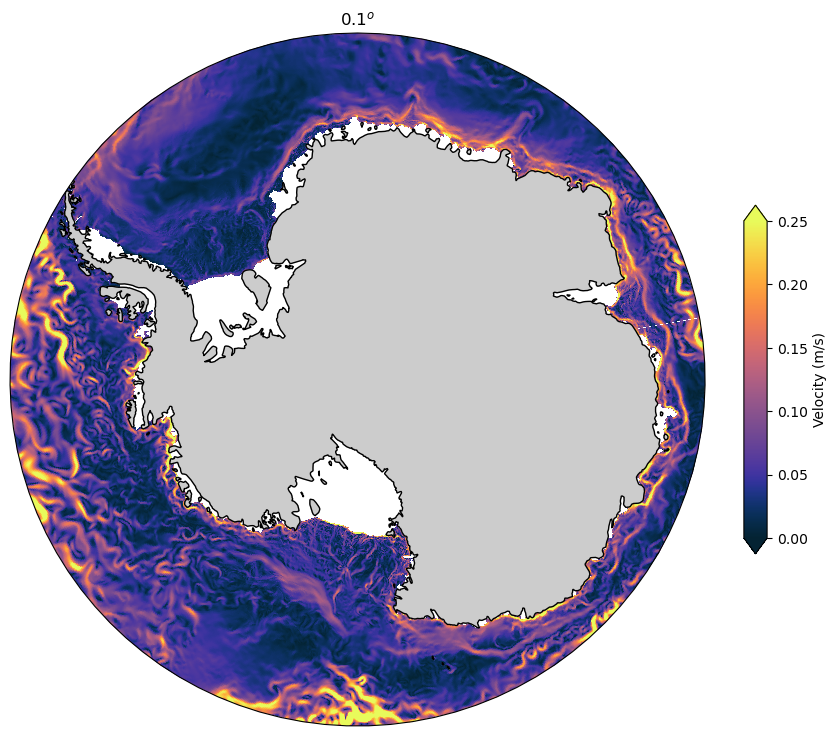

In [41]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)



projection = ccrs.SouthPolarStereo()

plt.figure(figsize=(10, 9))
ax = plt.axes(projection=projection)

ax.set_extent([-280, 80, -80, -63], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')

# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

VVEL01.plot(x='xq', y='yh',
         transform=ccrs.PlateCarree(),
         vmin=0, vmax=0.25, extend='both',
         cmap=cm.cm.thermal,
         cbar_kwargs = {'label': 'Velocity (m/s)',
                        'fraction': 0.03,
                        'aspect': 15,
                        'shrink': 0.7})

plt.title(r'$0.1^o$')

Text(0.5, 1.0, '$0.05^o$')

<Figure size 1000x1000 with 0 Axes>

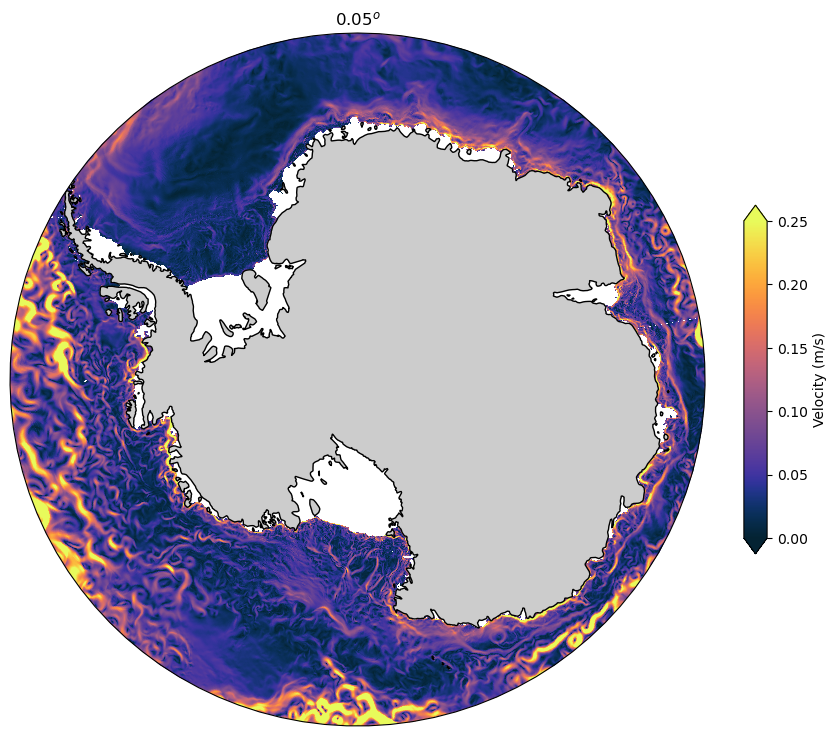

In [42]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)



projection = ccrs.SouthPolarStereo()

plt.figure(figsize=(10, 9))
ax = plt.axes(projection=projection)

ax.set_extent([-280, 80, -80, -63], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')

# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

VVEL005.plot(x='xq', y='yh',
         transform=ccrs.PlateCarree(),
         vmin=0, vmax=0.25, extend='both',
         cmap=cm.cm.thermal,
         cbar_kwargs = {'label': 'Velocity (m/s)',
                        'fraction': 0.03,
                        'aspect': 15,
                        'shrink': 0.7})

plt.title(r'$0.05^o$')

Text(0.5, 1.0, '$0.025^o$')

<Figure size 1000x1000 with 0 Axes>

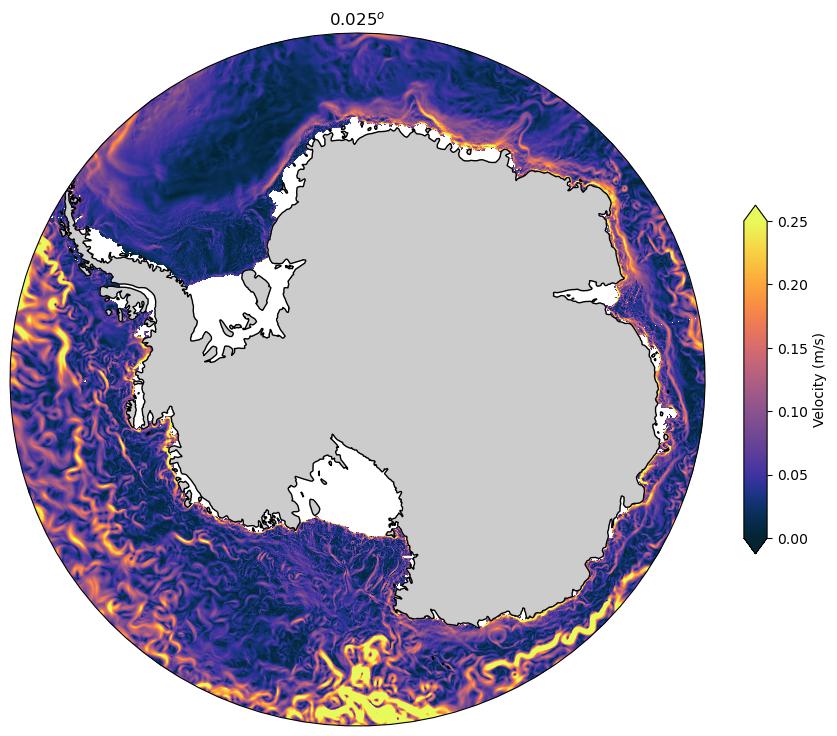

In [43]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)



projection = ccrs.SouthPolarStereo()

plt.figure(figsize=(10, 9))
ax = plt.axes(projection=projection)

ax.set_extent([-280, 80, -80, -63], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')

# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.

import matplotlib.path as mpath

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

VVEL0025.plot(x='xq', y='yh',
         transform=ccrs.PlateCarree(),
         vmin=0, vmax=0.25, extend='both',
         cmap=cm.cm.thermal,
         cbar_kwargs = {'label': 'Velocity (m/s)',
                        'fraction': 0.03,
                        'aspect': 15,
                        'shrink': 0.7})

plt.title(r'$0.025^o$')

Text(0.5, 1.0, '$0.1^o$')

<Figure size 1000x1000 with 0 Axes>

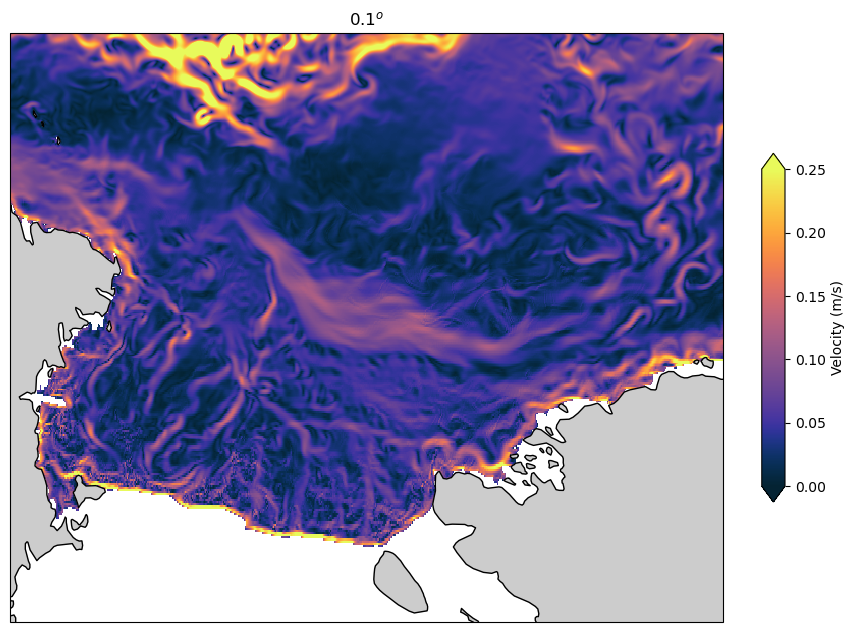

In [51]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)


projection = ccrs.Mercator(central_longitude=-60, min_latitude=-85.0, max_latitude=-60.0)

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=projection)

ax.set_extent([-200, -130, -80, -63], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')


VVEL01.plot(x='xq', y='yh',
         transform=ccrs.PlateCarree(),
         vmin=0, vmax=0.25, extend='both',
         cmap=cm.cm.thermal,
         cbar_kwargs = {'label': 'Velocity (m/s)',
                        'fraction': 0.03,
                        'aspect': 15,
                        'shrink': 0.7})

plt.title(r'$0.1^o$')

Text(0.5, 1.0, '$0.05^o$')

<Figure size 1000x1000 with 0 Axes>

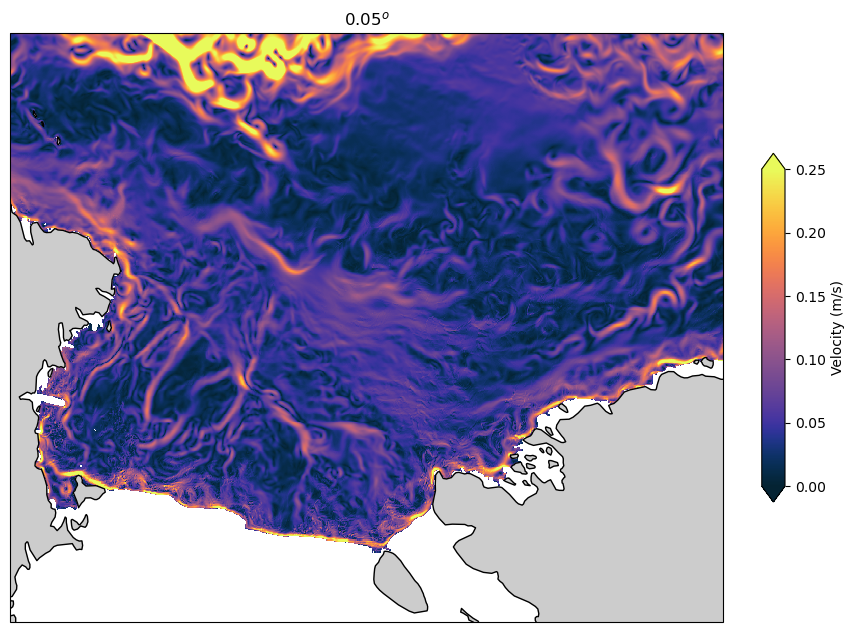

In [52]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)


projection = ccrs.Mercator(central_longitude=-60, min_latitude=-85.0, max_latitude=-60.0)

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=projection)

ax.set_extent([-200, -130, -80, -63], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')


VVEL005.plot(x='xq', y='yh',
         transform=ccrs.PlateCarree(),
         vmin=0, vmax=0.25, extend='both',
         cmap=cm.cm.thermal,
         cbar_kwargs = {'label': 'Velocity (m/s)',
                        'fraction': 0.03,
                        'aspect': 15,
                        'shrink': 0.7})

plt.title(r'$0.05^o$')

Text(0.5, 1.0, '$0.025^o$')

<Figure size 1000x1000 with 0 Axes>

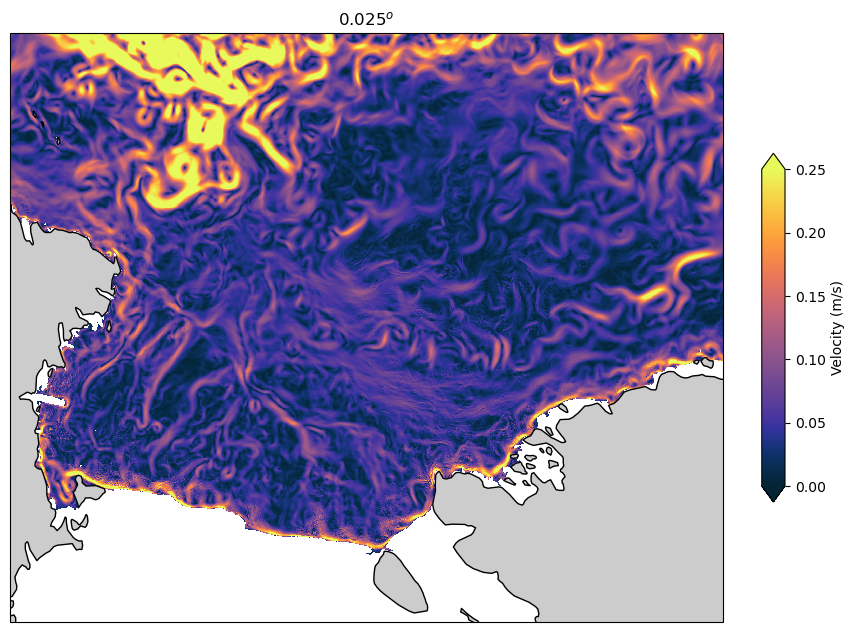

In [53]:
plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)


projection = ccrs.Mercator(central_longitude=-60, min_latitude=-85.0, max_latitude=-60.0)

plt.figure(figsize=(10, 10))
ax = plt.axes(projection=projection)

ax.set_extent([-200, -130, -80, -63], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')


VVEL0025.plot(x='xq', y='yh',
         transform=ccrs.PlateCarree(),
         vmin=0, vmax=0.25, extend='both',
         cmap=cm.cm.thermal,
         cbar_kwargs = {'label': 'Velocity (m/s)',
                        'fraction': 0.03,
                        'aspect': 15,
                        'shrink': 0.7})

plt.title(r'$0.025^o$')